# Average Adjusted PnL Curve

Aggregate the adjusted backtest `pnl_series.pkl` files for a specific strategy,
average them element-wise until the shortest series ends, and visualise the
resulting mean PnL with a drawdown panel.

In [109]:
# Imports and configuration
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FACTOR_NAME = "cnn_10_03_72h_v4_wma_1h_0.8"
STRATEGY_DIR = "lev_3_backtest_profit_20_stop_30"

ADJUST_DIR = Path.cwd() / "factor_report" / FACTOR_NAME / "adjust_backtest"
TARGET_DATE_RANGES = [
    "20250402_0300_20250831_2300",
    "20250402_0700_20250831_2300",
    "20250402_1100_20250831_2300",
    "20250402_1500_20250831_2300",
]

PNL_FILES = []
for date_range in TARGET_DATE_RANGES:
    glob_pattern = f"{date_range}/{STRATEGY_DIR}/*/pnl_series.pkl"
    PNL_FILES.extend(sorted(ADJUST_DIR.glob(glob_pattern)))

PNL_FILES

[PosixPath('/home/craz/crypto/crypto-trading/strategy/backtest/factor_report/cnn_10_03_72h_v4_wma_1h_0.8/adjust_backtest/20250402_0300_20250831_2300/lev_3_backtest_profit_20_stop_30/16h_top2_bottom2/pnl_series.pkl'),
 PosixPath('/home/craz/crypto/crypto-trading/strategy/backtest/factor_report/cnn_10_03_72h_v4_wma_1h_0.8/adjust_backtest/20250402_0700_20250831_2300/lev_3_backtest_profit_20_stop_30/16h_top2_bottom2/pnl_series.pkl'),
 PosixPath('/home/craz/crypto/crypto-trading/strategy/backtest/factor_report/cnn_10_03_72h_v4_wma_1h_0.8/adjust_backtest/20250402_1100_20250831_2300/lev_3_backtest_profit_20_stop_30/16h_top2_bottom2/pnl_series.pkl'),
 PosixPath('/home/craz/crypto/crypto-trading/strategy/backtest/factor_report/cnn_10_03_72h_v4_wma_1h_0.8/adjust_backtest/20250402_1500_20250831_2300/lev_3_backtest_profit_20_stop_30/16h_top2_bottom2/pnl_series.pkl')]

In [110]:
# Load PnL series and compute element-wise mean up to the shortest series
if not PNL_FILES:
    raise FileNotFoundError("No pnl_series.pkl files found; check the factor or strategy name.")

series_list = []
for path in PNL_FILES:
    series = pd.read_pickle(path)
    if not isinstance(series, pd.Series):
        raise TypeError(f"Expected pandas Series in {path}, got {type(series)}")
    series = series.sort_index()
    series_list.append(series)

min_length = min(len(s) for s in series_list)
trimmed = [s.iloc[:min_length] for s in series_list]
values = np.stack([s.values for s in trimmed])
mean_values = values.mean(axis=0)

mean_pnl = pd.Series(mean_values, index=trimmed[0].index, name="average_pnl")

print(f"Loaded {len(series_list)} series; averaging the first {min_length} observations.")
mean_pnl.head()

Loaded 4 series; averaging the first 227 observations.


2025-04-02 03:00:00    0.987269
2025-04-02 19:00:00    0.989603
2025-04-03 11:00:00    1.040237
2025-04-04 03:00:00    1.024430
2025-04-04 19:00:00    0.941152
Name: average_pnl, dtype: float64

In [111]:
# Plot helper inspired by adjust_backtest.plot_pnl_curve
def plot_average_pnl(pnl_series: pd.Series, title: str) -> None:
    if len(pnl_series) < 2:
        raise ValueError("Insufficient data points to plot.")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

    ax1.plot(pnl_series.index, pnl_series.values, linewidth=2, color="#2E86AB", label="Average PnL")
    ax1.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, alpha=0.5, label="Initial")
    ax1.fill_between(pnl_series.index, 1.0, pnl_series.values, where=(pnl_series.values >= 1.0), alpha=0.3, color="green", interpolate=True)
    ax1.fill_between(pnl_series.index, 1.0, pnl_series.values, where=(pnl_series.values < 1.0), alpha=0.3, color="red", interpolate=True)

    ax1.set_title(title, fontsize=16, fontweight="bold")
    ax1.set_xlabel("Date", fontsize=12)
    ax1.set_ylabel("PnL (Cumulative)", fontsize=12)
    ax1.legend(loc="best", fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

    total_return = (pnl_series.iloc[-1] / pnl_series.iloc[0] - 1) * 100
    stats_text = f"Total Return: {total_return:.2f}%\nFinal PnL: {pnl_series.iloc[-1]:.4f}"
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, fontsize=10, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    running_max = pnl_series.expanding().max()
    drawdown = (pnl_series - running_max) / running_max * 100
    ax2.fill_between(drawdown.index, 0, drawdown.values, color="red", alpha=0.5)

    ax2.set_xlabel("Date", fontsize=12)
    ax2.set_ylabel("Drawdown (%)", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

    max_dd = drawdown.min()
    ax2.text(0.02, 0.02, f"Max Drawdown: {max_dd:.2f}%", transform=ax2.transAxes, fontsize=10, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    plt.tight_layout()
    plt.show()

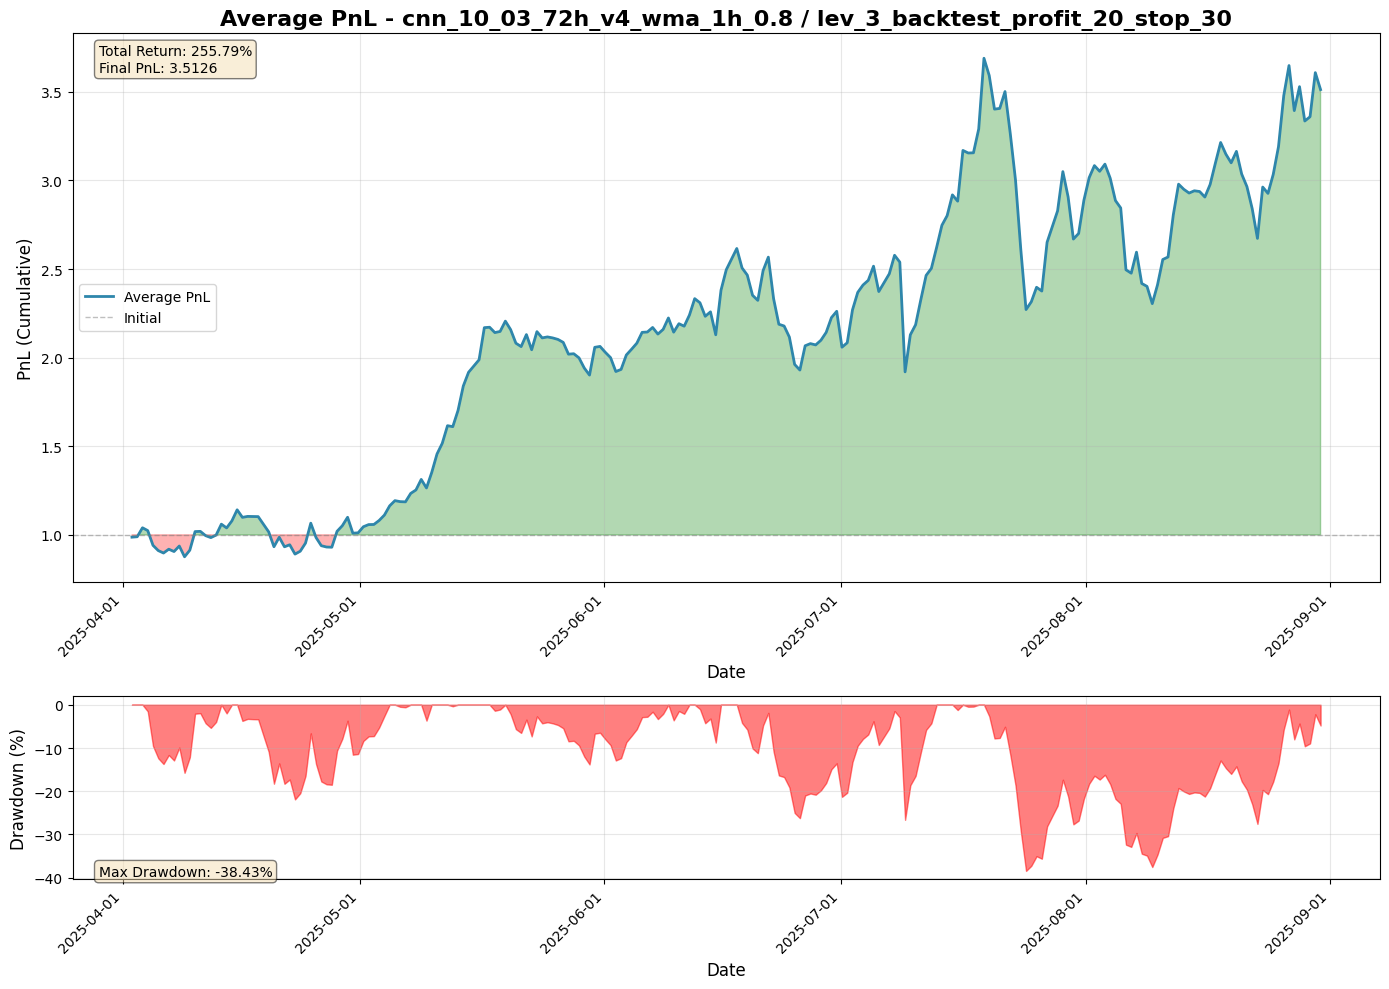

In [112]:
# Plot the averaged PnL
plot_title = f"Average PnL - {FACTOR_NAME} / {STRATEGY_DIR}"
plot_average_pnl(mean_pnl, title=plot_title)